# 1.0 Import Model

In [ ]:
import tensorflow as tf
import os
from tensorflow.keras.models import Model, load_model
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


In [ ]:
os.chdir('For Victor/amfinder-release-v2.1.2/amfinder/amf')
print(os.getcwd())
print(os.listdir())

/home/victor/Saliency Maps/For Victor/amfinder-release-v2.1.2/amfinder/amf
['colonized_activations.npy', 'all_activations.npy', 'amf', 'amfinder_predict.py', 'spatial_colonized_activations.npy', 'requirements_dev.txt', 'amfinder_config.py', 'requirements.txt', 'filter_visualization.py', 'embeddings_full_mis.npy', 'no_root_activations.npy', 'uncolonized_activations.npy', 'Correctly classified vs Misclassified data histogram plot.png', 'pure_purple_analysis.py', 'amfinder_model.py', 'amfinder_diagnose.py', 'Correct Data vs Misclassified Data for non-colonized roots.png', 'test_metrics.py', 'visualize_UMAP.py', 'trained_networks', 'amfinder_load.py', 'amfinder_tile_convert.py', '__pycache__', 'amfinder_test.py', 'amfinder_segmentation.py', 'install.sh', 'amfinder_image.py', 'metrics_collector.py', 'amfinder_altmodel.py', 'amfinder_calc.py', 'preprocessing.py', 'build', 'amfinder_plot.py', 'amfinder_train.py', 'split_data.py', 'amfinder_save.py', 'amfinder_superresolution.py', 'spatial_unc

In [ ]:
from filter_visualization import static_filter_activations, visualize_layer_activations

In [ ]:
from visualize_activations import static_filter_activations, visualize_layer_activations, predict_labels

In [ ]:
%matplotlib inline

In [ ]:
model = load_model('trained_networks/252_tile.h5')

I0000 00:00:1738312031.875367   50564 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:2d:00.0, compute capability: 7.5
/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
model.summary()

Model: "col"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 252, 252, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C11 (Conv2D)                    │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C12 (Conv2D)                    │ (None, 248, 248, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C13 (Conv2D)                    │ (None, 246, 246, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ M1 (MaxPooling2D)               │ (None, 123, 123, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C21 (Conv2D)                    │ (None, 121, 121, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C22 (Conv2D)                    │ (None, 119, 119, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ M2 (MaxPooling2D)               │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C31 (Conv2D)                    │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C32 (Conv2D)                    │ (None, 55, 55, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ M3 (MaxPooling2D)               │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C4 (Conv2D)                     │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ M4 (MaxPooling2D)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F (Flatten)                     │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FCRS1 (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DRS1 (Dropout)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FCRS2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DRS2 (Dropout)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RS (Dense)                      │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,318,597 (20.29 MB)

 Trainable params: 5,318,595 (20.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#Load sample data
x_0 = np.load("Preprocessed_data/Data/Test/x_test_spring_0.npy")
y_0 = np.load("Preprocessed_data/Labels/True/y_test_spring_0.npy")
#x_1 = np.load("Spring_preprocessed/x_test_spring_1.npy")
print(x_0.shape)


(582, 252, 252, 3)


In [ ]:
layer_name = "C11"

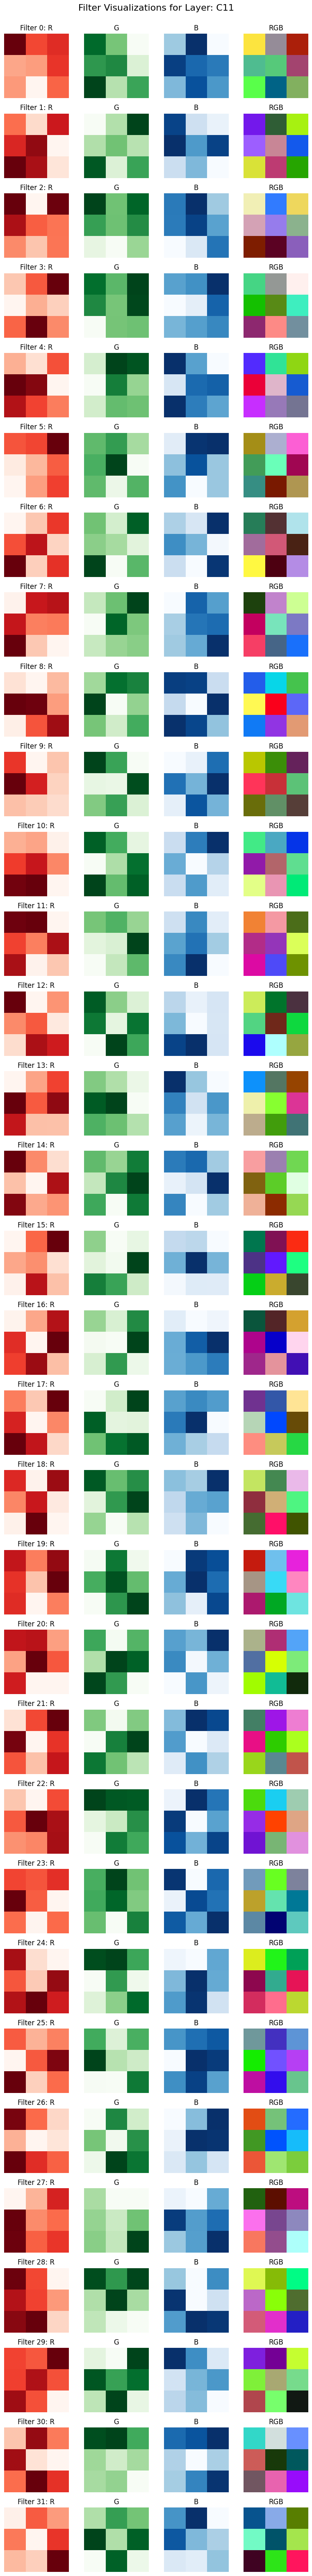

In [ ]:
#static filter activations refer to the activations that maximally activation each filter
static_filter_activations(model=model, layer_name='C11')

In [ ]:
colonized = []
uncolonized = []
no_root = []
for tile_index, tile in enumerate(y_0):
    for i, v in enumerate(tile):
        if v == 1:
            if i == 0:
                colonized.append(tile_index) 
            if i == 1:
                uncolonized.append(tile_index)
            if i == 2:
                no_root.append(tile_index)

In [ ]:
print(colonized)
print(uncolonized)
print(no_root)

[39, 41, 47, 48, 56, 66, 67, 71, 80, 81, 113, 122, 123, 252, 263, 277, 278, 298, 315, 316, 323, 324, 332, 350, 351, 375, 376, 377]
[40, 42, 44, 46, 53, 54, 57, 61, 62, 65, 69, 70, 72, 77, 78, 82, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 100, 101, 102, 103, 105, 106, 107, 108, 109, 110, 112, 116, 117, 118, 119, 120, 127, 128, 129, 131, 132, 136, 137, 140, 146, 147, 152, 153, 155, 156, 159, 162, 163, 165, 166, 167, 173, 174, 175, 178, 179, 180, 181, 182, 183, 184, 185, 187, 188, 189, 190, 195, 196, 198, 199, 200, 201, 202, 203, 204, 205, 207, 209, 210, 211, 212, 213, 214, 215, 216, 217, 219, 220, 221, 222, 223, 225, 227, 228, 229, 230, 231, 232, 235, 236, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 253, 254, 255, 256, 257, 258, 259, 261, 262, 264, 265, 266, 269, 270, 271, 272, 274, 275, 276, 279, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 299, 300, 301, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 317, 318, 320, 321, 322, 325, 326,

[Colonized : 1, Non-colonized : 0, Background : 0]


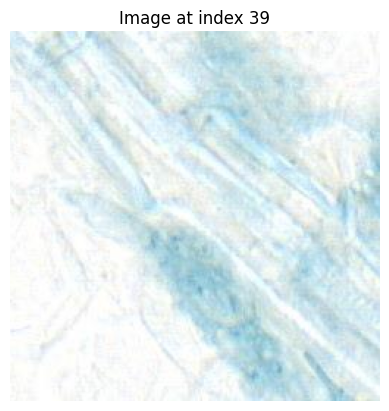

In [ ]:
# Index of the image to plot
index = 39  # Replace with your desired index
index_label = y_0[index] # NOTE FILE HAS TO BE REDIFINED
# Extract the image at index i
image = x_0[index]  # x has shape (582, 252, 252, 3)

# Plot the image
print(f'[Colonized : {index_label[0]}, Non-colonized : {index_label[1]}, Background : {index_label[2]}]')
plt.imshow(image.astype('uint8'))  # Ensure correct data type for display
plt.axis('off')  # Remove axes for better visualization
plt.title(f"Image at index {index}")
plt.show()


I0000 00:00:1738312056.476040   50721 service.cc:148] XLA service 0x7fdd98105590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738312056.476090   50721 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 08:27:36.482883: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738312056.510559   50721 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 08:27:36.699475: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config"

 5/19 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

I0000 00:00:1738312059.114009   50721 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

2025-01-31 08:27:40.308631: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,119,119]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,64,121,121]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 08:27:40.385067: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,128,57,57]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,64,59,59]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_co

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step
Number of filters with no informative activation (pure purple): 118


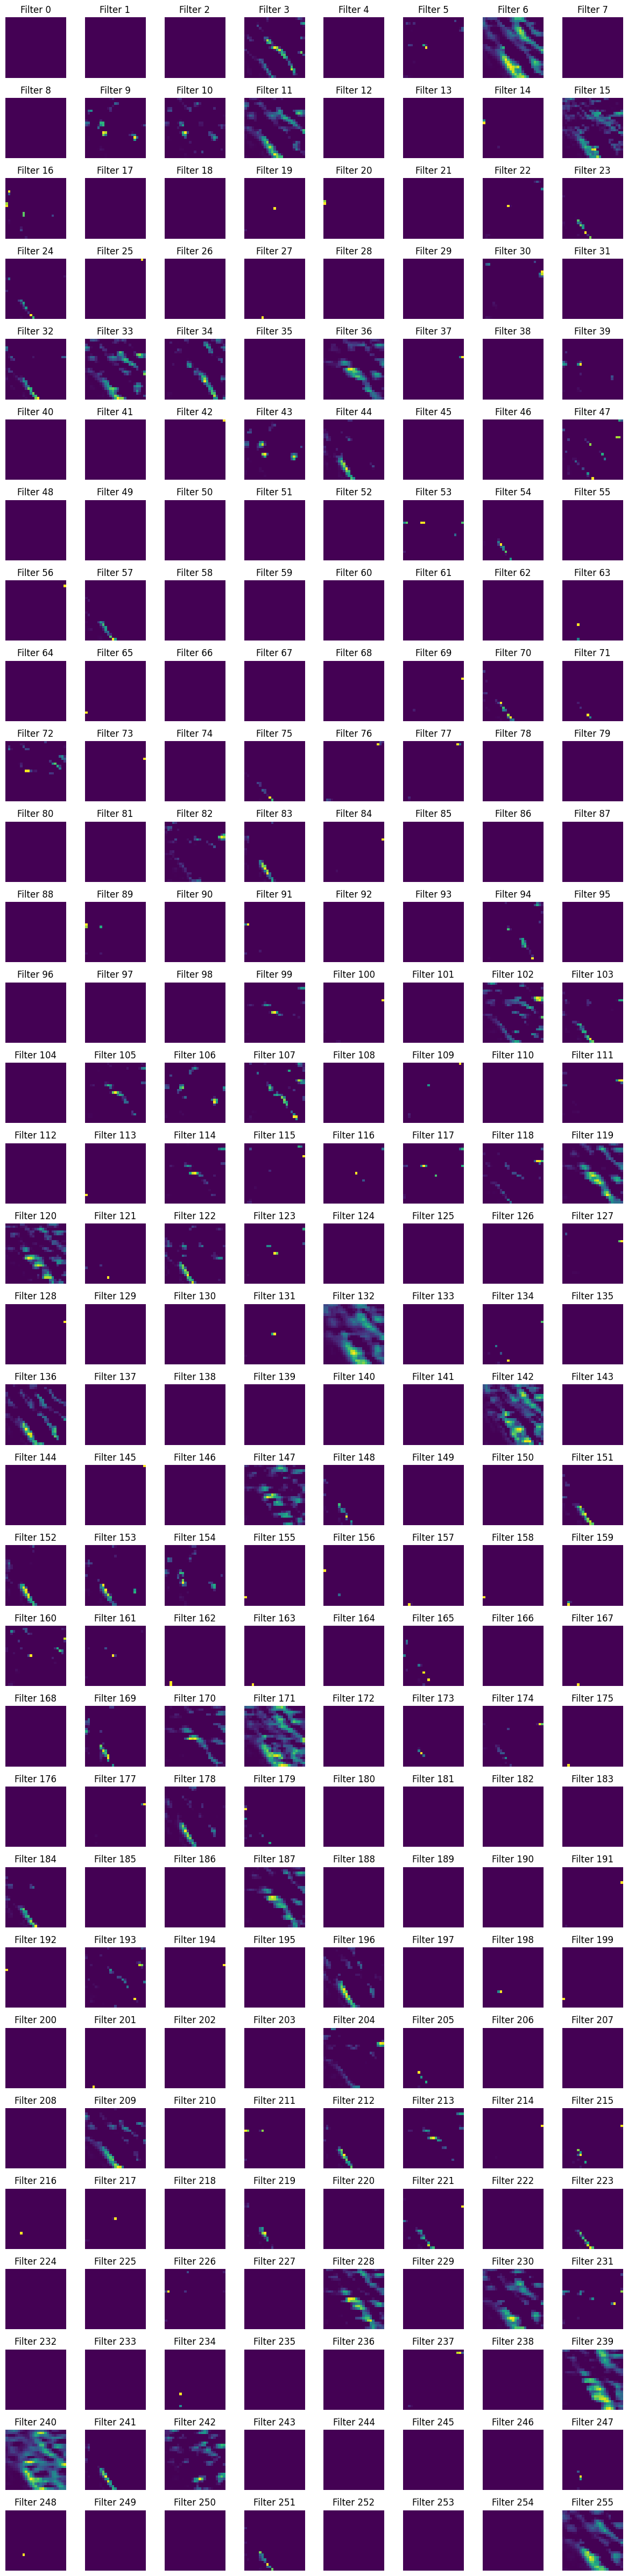

In [ ]:
visualize_layer_activations(model = model, image=x_0, index = index, layer_name = 'C4')